In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
fred = pd.read_csv('../data/fred.csv')
fred.head(1)

,observation_date,PSAVERT
0,2015-01-01,6.3


In [3]:
usda = pd.read_csv('../data/usda_expenditures.csv')
usda.head(1)

,Year,Food at home expenditures million nominal U.S. dollars by households,Food at home expenditures million nominal U.S. dollars by government,Food at home expenditures million nominal U.S. dollars by home production,Food at home expenditures million constant 1988 U.S. dollars by households,Food at home expenditures million constant 1988 U.S. dollars by government,Food at home expenditures million constant 1988 U.S. dollars by home production,Food away from home expenditures million nominal U.S. dollars by households,Food away from home expenditures million nominal U.S. dollars by government,Food away from home expenditures million nominal U.S. dollars by home production,Food away from home expenditures million constant 1988 U.S. dollars by households,Food away from home expenditures million constant 1988 U.S. dollars by government,Food away from home expenditures million constant 1988 U.S. dollars by home production
0,1997,"351,807.63","23,677.15",842.93,"259,460.91","17,462.09",621.67,"265,068.59","16,615.44","54,711.66","205,639.20","12,890.19","42,445.10"


In [4]:
fred['observation_date'] = pd.to_datetime(fred['observation_date'])
fred['Year'] = fred['observation_date'].dt.year
fred.head(1)

,observation_date,PSAVERT,Year
0,2015-01-01,6.3,2015


In [5]:
fred_annual = fred.groupby('Year')['PSAVERT'].mean().reset_index()
fred_annual.head(1)

,Year,PSAVERT
0,2015,5.85


In [6]:
usda_filtered = usda[['Year', 
                  'Food at home expenditures million nominal U.S. dollars by households',
                  'Food away from home expenditures million nominal U.S. dollars by households']]
usda_filtered.head(1)

,Year,Food at home expenditures million nominal U.S. dollars by households,Food away from home expenditures million nominal U.S. dollars by households
0,1997,"351,807.63","265,068.59"


In [7]:
usda_filtered.rename(columns={
    'Food at home expenditures million nominal U.S. dollars by households': 'Food At Home Expenditures',
    'Food away from home expenditures million nominal U.S. dollars by households': 'Food Away From Home Expenditures'
}, inplace=True)
usda_filtered.head(1)

C:\Users\user\AppData\Local\Temp\ipykernel_10832\131430342.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usda_filtered.rename(columns={


,Year,Food At Home Expenditures,Food Away From Home Expenditures
0,1997,"351,807.63","265,068.59"


In [8]:
combined = pd.merge(fred_annual, usda_filtered, on='Year', how='inner')
combined.head()

,Year,PSAVERT,Food At Home Expenditures,Food Away From Home Expenditures
0,2015,5.850000,"655,173.63","675,332.75"
1,2016,5.358333,"669,631.38","717,941.31"
2,2017,5.758333,"700,405.31","768,070.00"
3,2018,6.433333,"731,098.63","815,998.06"
4,2019,7.308333,"761,813.06","845,048.00"


<Figure size 1200x600 with 0 Axes>

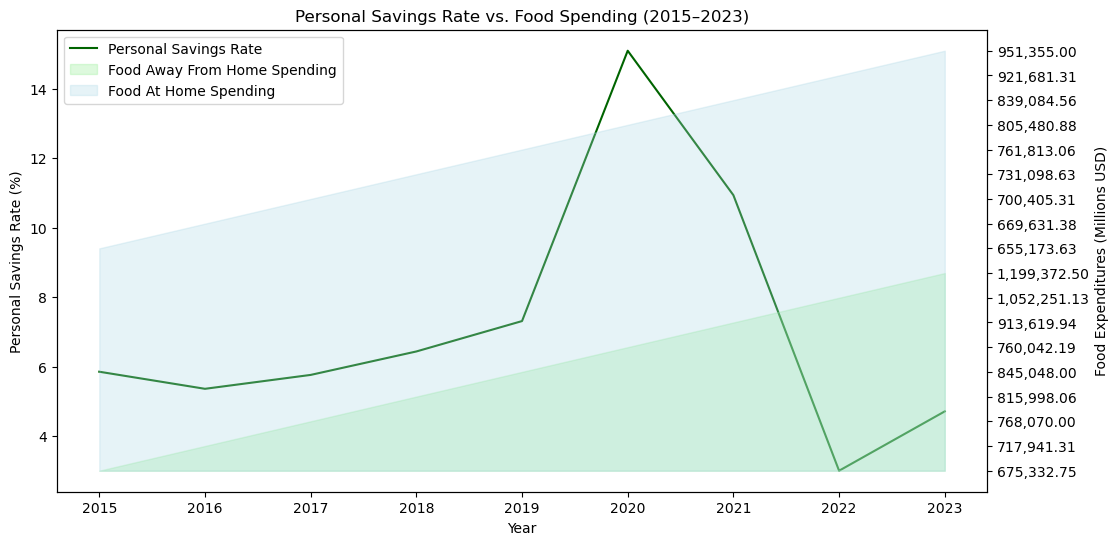

In [9]:
plt.figure(figsize=(12, 6))
fig, savings_axis = plt.subplots(figsize=(12, 6))
savings_color = 'darkgreen'
savings_axis.plot(combined['Year'], combined['PSAVERT'], color=savings_color, label='Personal Savings Rate')
savings_axis.set_ylabel('Personal Savings Rate (%)', color='black')
savings_axis.tick_params(axis='y', labelcolor='black')

spending_axis = savings_axis.twinx()
fafh_color = 'lightgreen'
spending_axis.fill_between(combined['Year'],
                           combined['Food Away From Home Expenditures'],
                           color=fafh_color,
                           alpha=0.3,
                           label='Food Away From Home Spending')
fah_color = 'lightblue'
spending_axis.fill_between(combined['Year'],
                           combined['Food At Home Expenditures'],
                           color=fah_color,
                           alpha=0.3,
                           label='Food At Home Spending')
spending_axis.set_ylabel('Food Expenditures (Millions USD)', color='black')
savings_axis.set_xlabel('Year')

lines_savings, labels_savings = savings_axis.get_legend_handles_labels()
lines_spending, labels_spending = spending_axis.get_legend_handles_labels()

savings_axis.legend(lines_savings + lines_spending,
                    labels_savings + labels_spending,
                    loc='upper left')
                   
plt.title('Personal Savings Rate vs. Food Spending (2015–2023)')
plt.savefig('savings_food_spending.png', dpi=300, bbox_inches='tight')
plt.show()